In [1]:
!pip install yfinance pandas matplotlib

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

stocks = ["AAPL", "MSFT", "JPM"]

data = yf.download(
    stocks,
    start="2023-01-01",
    end="2026-01-01",
    auto_adjust=True
)

print(data.head())


[*********************100%***********************]  3 of 3 completed

Price            Close                                High              \
Ticker            AAPL         JPM        MSFT        AAPL         JPM   
Date                                                                     
2023-01-03  122.876747  123.735184  232.510544  128.604505  125.218697   
2023-01-04  124.144112  124.889023  222.339813  126.403781  126.079477   
2023-01-05  122.827614  124.861343  215.750137  125.529389  125.193447   
2023-01-06  127.346962  127.250641  218.292862  128.005211  127.656546   
2023-01-09  127.867622  126.724792  220.418228  131.070463  128.117787   

Price                          Low                                Open  \
Ticker            MSFT        AAPL         JPM        MSFT        AAPL   
Date                                                                     
2023-01-03  238.498479  121.992528  122.608824  230.394863  127.995383   
2023-01-04  225.998559  122.886559  124.147273  219.292468  124.664816   
2023-01-05  220.835522  122.572179  1

In [3]:
# Get the daily closing prices
prices = data["Close"]

# Calculate daily percentage returns
daily_returns = prices.pct_change()

# Calculate total return over the entire period
total_returns = (prices.iloc[-1] / prices.iloc[0] - 1) * 100

print("Total Returns (%)")
print(total_returns.round(2))

Total Returns (%)
Ticker
AAPL    120.65
JPM     156.76
MSFT    106.69
dtype: float64


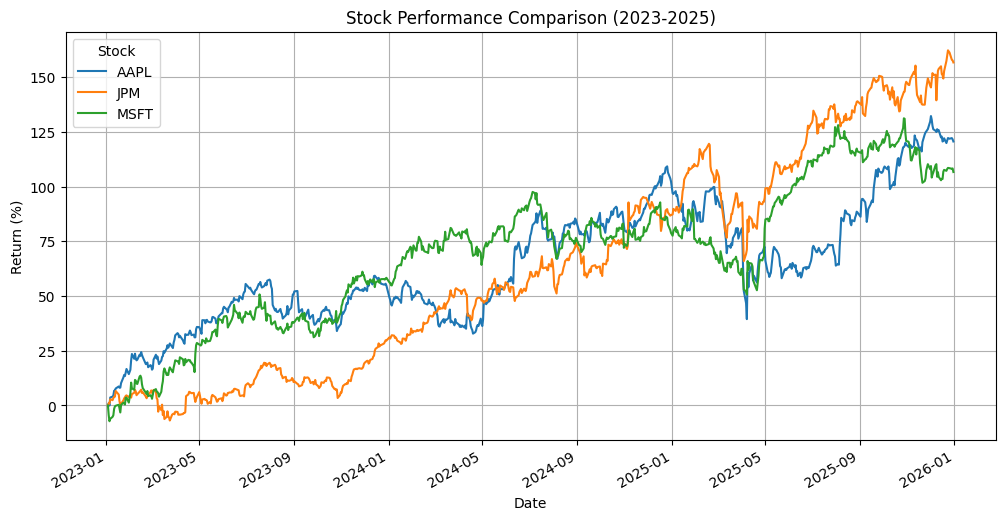

In [4]:
# Convert prices into percentage growth from the start
growth = (prices / prices.iloc[0] - 1) * 100

# Plot the results
growth.plot(figsize=(12, 6))

plt.title("Stock Performance Comparison (2023-2025)")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.legend(title="Stock")
plt.grid(True)

plt.show()

In [5]:
# Calculate annualized volatility
volatility = daily_returns.std() * (252 ** 0.5) * 100

print("Annualized Volatility (%)")
print(volatility.round(2))

Annualized Volatility (%)
Ticker
AAPL    25.60
JPM     23.08
MSFT    23.20
dtype: float64


In [6]:
# Create a summary table of financial performance

summary = pd.DataFrame({
    "Total Return (%)": total_returns,
    "Annualized Volatility (%)": volatility
})

summary = summary.round(2)

print(summary)

        Total Return (%)  Annualized Volatility (%)
Ticker                                             
AAPL              120.65                      25.60
JPM               156.76                      23.08
MSFT              106.69                      23.20


In [7]:
# Find the stock with the highest total return
best_return = total_returns.idxmax()

# Find the stock with the highest volatility
highest_volatility = volatility.idxmax()

print("Highest total return:", best_return)
print("Highest volatility:", highest_volatility)

Highest total return: JPM
Highest volatility: AAPL


In [8]:
print(
    best_return,
    "had the highest total return of",
    round(total_returns[best_return], 2),
    "%"
)

print(
    highest_volatility,
    "had the highest annualized volatility of",
    round(volatility[highest_volatility], 2),
    "%"
)

JPM had the highest total return of 156.76 %
AAPL had the highest annualized volatility of 25.6 %


## Key Findings

**1. Stock Performance:** From January 2023 through December 2025, Apple had the highest total return of 120.65%, compared to Microsoft & JPMorgan Chase. This indicates that Apple experienced the greatest price appreciation among the three stocks during the selected period.

**2. Volatility and Risk:** Apple had the highest annualized volatility at 25.6%, indicating that its daily returns fluctuated more than those of the other stocks during the period.

**3. Overall Comparison:** Comparing total returns and volatility shows that historical performance differed across the three companies. Apple had both the highest total return and the highest annualized volatility among the three stocks. This suggests that while Apple provided the greatest returns during the period analyzed, its stock price also experienced larger fluctuations. This demonstrates the relationship between potential returns and investment risk, as stocks with higher returns may also involve greater volatility.


In [9]:
# Export the summary table
summary.to_csv("stock_performance_summary.csv")

print("Summary exported successfully!")

Summary exported successfully!


In [11]:
daily_returns.to_csv("daily_stock_returns.csv")